In [16]:
import pandas as pd

def processingdata():
    df = pd.read_csv("../Dataset/healthcare-dataset-stroke-data.csv")  # Load the dataset
    dictn = {}  # To store encoding mappings for categorical columns
    cols = df.select_dtypes(include=["object"]).columns  # Identify categorical columns

    for col in df.columns:
        if col in cols:
            # Handle missing values in categorical columns using the mode
            df[col] = df[col].fillna(df[col].mode()[0])
            
            # Encode unique categorical values into integers
            uni_vals = df[col].unique()
            mpp = {val: i for i, val in enumerate(uni_vals)}
            df[col] = df[col].map(mpp)
            
            # Store the mapping for possible reverse conversion or analysis
            dictn[col] = mpp
        else:
            # Convert values to numeric and handle non-convertible entries as NaN
            df[col] = pd.to_numeric(df[col], errors="coerce")
            
            # Fill missing numeric values with the column mean
            df[col] = df[col].fillna(df[col].mean())
    
    return df, dictn

# Run the preprocessing and inspect results
df, dictn = processingdata()
print(df.head())     # View first few rows of processed data
print(dictn)         # View mappings used for categorical columns


      id  gender   age  hypertension  heart_disease  ever_married  work_type  \
0   9046       0  67.0             0              1             0          0   
1  51676       1  61.0             0              0             0          1   
2  31112       0  80.0             0              1             0          0   
3  60182       1  49.0             0              0             0          0   
4   1665       1  79.0             1              0             0          1   

   Residence_type  avg_glucose_level        bmi  smoking_status  stroke  
0               0             228.69  36.600000               0       1  
1               1             202.21  28.893237               1       1  
2               1             105.92  32.500000               1       1  
3               0             171.23  34.400000               2       1  
4               1             174.12  24.000000               1       1  
{'gender': {'Male': 0, 'Female': 1, 'Other': 2}, 'ever_married': {'Yes': 0,

Logistic Regression Before PCA

In [ ]:
# Load the dataset after cleaning and encoding via the custom preprocessing function
processed_df, label_maps = processingdata()

# Import necessary modules for data preparation and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Define the input features (X) and the target label (y)
# Dropping 'id' since it's just an identifier and 'stroke' is the target
features = processed_df.drop(columns=['id', 'stroke'])
target = processed_df['stroke']

# Standardize the feature values to ensure all features are on the same scale
# This helps models like logistic regression converge faster
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)


# Using 80% of the data for training and 20% for testing
# Setting a fixed random_state ensures reproducibility of the results
X_train, X_test, y_train, y_test = train_test_split(
    features_scaled, target, test_size=0.2, random_state=42
)


In [27]:
import numpy as np

class MyLogisticModel:
    def __init__(self, lr=0.01, iterations=1000):
        # Set initial learning rate and the total number of update cycles (epochs)
        self.lr = lr
        self.iterations = iterations
        self.coefficients = None  # Feature weights initialized later
        self.intercept = None     # Scalar bias term

    def _sigmoid(self, z):
        # This helper function applies the sigmoid transformation
        # It maps any real-valued number into the (0, 1) interval
        return 1 / (1 + np.exp(-z))

    def train(self, X, y):
        # Get the dimensions of the input data
        num_samples, num_features = X.shape

        # Initialize model parameters with zeros
        self.coefficients = np.zeros(num_features)
        self.intercept = 0

        # Compute weights to handle imbalanced class distributions
        weight_0 = len(y) / (2 * np.sum(y == 0))
        weight_1 = len(y) / (2 * np.sum(y == 1))
        class_weights = np.where(y == 1, weight_1, weight_0)

        # Begin the training loop using gradient descent
        for _ in range(self.iterations):
            # Compute linear output (dot product of features and weights + bias)
            linear_pred = np.dot(X, self.coefficients) + self.intercept

            # Use sigmoid to get probability-like output
            predictions = self._sigmoid(linear_pred)

            # Calculate the difference between predictions and actual labels
            errors = predictions - y

            # Apply class-specific weights to the errors
            weighted_errors = class_weights * errors

            # Compute gradient of loss with respect to weights and bias
            dw = (1 / num_samples) * np.dot(X.T, weighted_errors)
            db = (1 / num_samples) * np.sum(weighted_errors)

            # Update parameters in the direction of minimizing the loss
            self.coefficients -= self.lr * dw
            self.intercept -= self.lr * db

    def classify(self, X):
        # Compute the weighted sum of inputs and the intercept term
        linear_output = np.dot(X, self.coefficients) + self.intercept

        # Apply sigmoid activation to turn linear scores into probabilities
        probabilities = self._sigmoid(linear_output)

        # Convert probabilities into binary class predictions (0 or 1)
        return np.where(probabilities >= 0.5, 1, 0)


In [29]:
# Convert target values from pandas Series to NumPy arrays
# This format is better suited for mathematical operations within our custom model
train_labels = y_train.to_numpy()
test_labels = y_test.to_numpy()

# Create and initialize an instance of the custom logistic regression model
# Hyperparameters: learning rate and number of iterations for gradient descent
log_model = MyLogisticModel(lr=0.01, iterations=1000)

# Train the model using the training feature set and corresponding labels
log_model.train(X_train, train_labels)

# Use the trained model to make predictions on the unseen test set
predicted_labels = log_model.classify(X_test)

# Evaluate how well the model performs by comparing predicted and actual labels
print("Accuracy:", accuracy_score(test_labels, predicted_labels))

# Generate a classification report: includes precision, recall, and F1-score
print("\nEvaluation Summary:\n", classification_report(test_labels, predicted_labels))


Accuracy: 0.6790606653620352

Evaluation Summary:
               precision    recall  f1-score   support

           0       0.98      0.67      0.80       960
           1       0.14      0.84      0.24        62

    accuracy                           0.68      1022
   macro avg       0.56      0.75      0.52      1022
weighted avg       0.93      0.68      0.76      1022



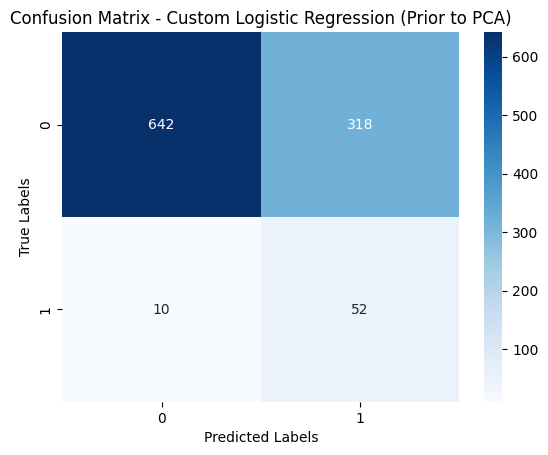

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix using predictions from the custom model
cm = confusion_matrix(test_labels, predicted_labels)

# Create a heatmap to visually represent the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# Add plot titles and labels for clarity
plt.title("Confusion Matrix - Custom Logistic Regression (Prior to PCA)")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


PCA Implementation

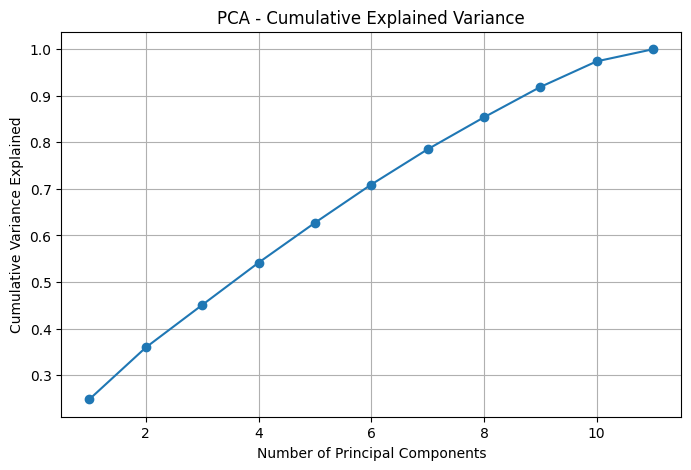

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Separate features and target variable
X = df.drop(columns=['stroke'])  # Features only
y = df['stroke']                 # Target labels

# Standardize the features to have zero mean and unit variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply Principal Component Analysis (PCA) to the scaled data
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Visualize how much variance is retained as components increase
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1), 
    pca.explained_variance_ratio_.cumsum(), 
    marker='o'
)
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('PCA - Cumulative Explained Variance')
plt.grid(True)
plt.show()

In [33]:
# Perform PCA with the number of components set to 9
pca_final = PCA(n_components=9)
X_pca_final = pca_final.fit_transform(X_scaled)

# Create a new DataFrame with the principal components
pca_df = pd.DataFrame(X_pca_final, columns=[f'PC{i+1}' for i in range(9)])

# Reattach the target variable to the PCA-transformed DataFrame
pca_df['stroke'] = y.values

# Preview the resulting DataFrame
pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,stroke
0,3.221169,3.283013,-1.537321,-0.297079,-1.297812,1.530022,1.783939,-0.945765,1.528919,1
1,1.245522,0.200973,1.128576,-0.067240,1.079238,0.309756,1.481981,-0.945867,-1.053727,1
2,2.426868,2.284803,0.573813,-0.461361,-2.074210,2.544963,-0.012649,0.580955,1.213932,1
3,1.108826,-0.366884,-0.254789,1.340682,0.859843,-0.172847,1.589078,0.337454,-0.355587,1
4,2.044716,1.247470,-0.160299,-2.110058,2.373079,-0.219169,-1.365524,-0.628045,-1.073827,1


Logistic Regression After PCA

In [34]:
# Logistic Regression on PCA-transformed features

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Split the reduced-dimension dataset into training and testing sets
X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    pca_df.drop('stroke', axis=1), 
    pca_df['stroke'], 
    test_size=0.2, 
    random_state=42
)

# Initialize and train a logistic regression model with balanced class weights
logreg_pca = LogisticRegression(class_weight='balanced')
logreg_pca.fit(X_pca_train, y_pca_train)

# Make predictions on the test set
y_pca_pred = logreg_pca.predict(X_pca_test)

# Evaluate performance using accuracy and a detailed classification report
print("Accuracy:", accuracy_score(y_pca_test, y_pca_pred))
print(classification_report(y_pca_test, y_pca_pred, target_names=["No Stroke", "Stroke"]))


Accuracy: 0.6976516634050881
              precision    recall  f1-score   support

   No Stroke       0.99      0.69      0.81       960
      Stroke       0.15      0.84      0.25        62

    accuracy                           0.70      1022
   macro avg       0.57      0.76      0.53      1022
weighted avg       0.93      0.70      0.78      1022



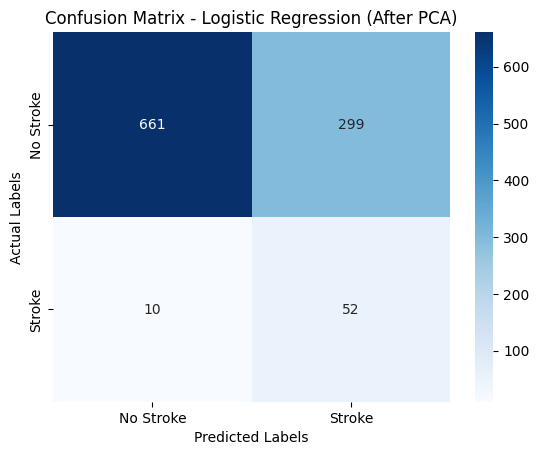

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix for PCA-based predictions
conf_matrix_pca = confusion_matrix(y_pca_test, y_pca_pred)

# Visualize the confusion matrix using a heatmap
sns.heatmap(conf_matrix_pca, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Stroke", "Stroke"],
            yticklabels=["No Stroke", "Stroke"])

# Add labels and title for better understanding
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("Confusion Matrix - Logistic Regression (After PCA)")
plt.show()